In [ ]:
from datasets import load_dataset
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

In [2]:
dataset = load_dataset("beans", split='train[:500]')
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 500
})

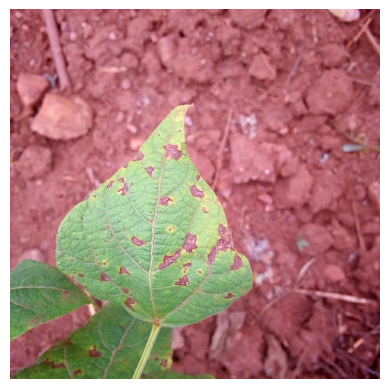

In [3]:
query_image_0 = dataset[65]['image']
plt.imshow(query_image_0)
plt.axis('off')
plt.show()

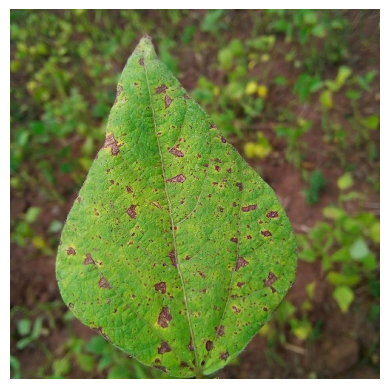

In [9]:
query_image_1 = dataset[4]['image']
plt.imshow(query_image_1)
plt.axis('off')
plt.show()

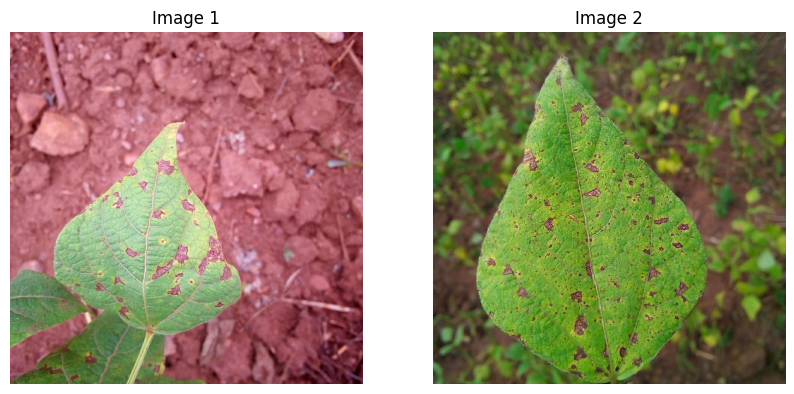

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(query_image_0)
plt.axis('off')
plt.title('Image 1')

plt.subplot(1, 2, 2)
plt.imshow(query_image_1)
plt.axis('off')
plt.title('Image 2')

plt.show()

비슷하게 생겼지만, color profile이 다름
- 다른 부수적인 요인들이 영향을 주었기 때문

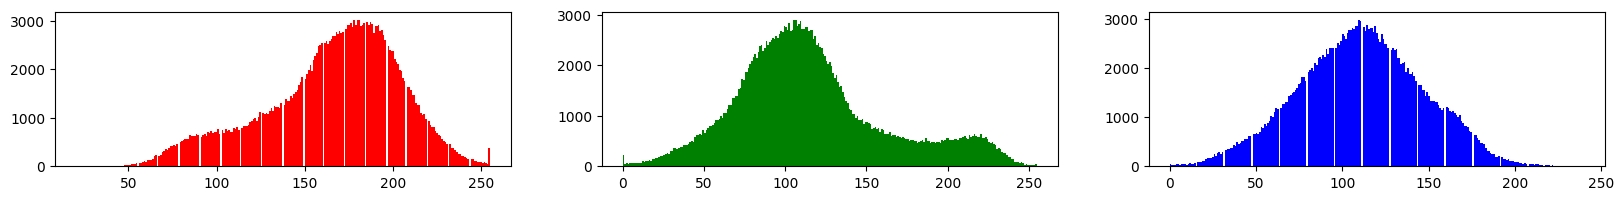

In [11]:
query_image_0 = np.array(query_image_0)
img_vector = query_image_0.reshape(1, -1, 3)

red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=255, color='r')
axs[1].hist(green_channel, bins=255, color='g')
axs[2].hist(blue_channel, bins=255, color='b')
plt.show()

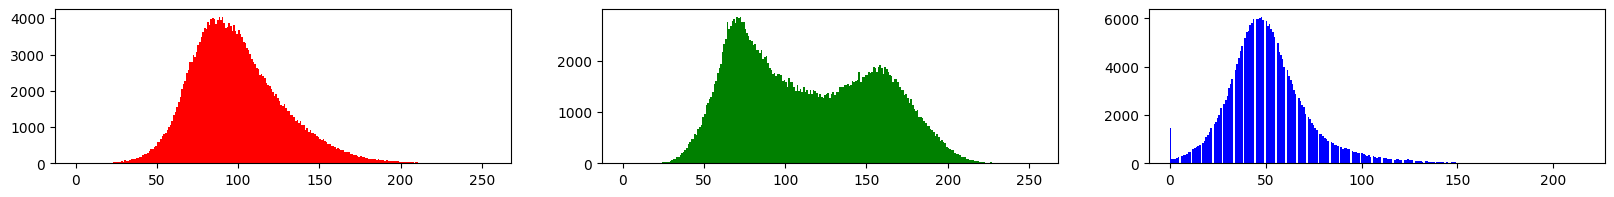

In [12]:
query_image_1 = np.array(query_image_1)
img_vector = query_image_1.reshape(1, -1, 3)

red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=255, color='r')
axs[1].hist(green_channel, bins=255, color='g')
axs[2].hist(blue_channel, bins=255, color='b')
plt.show()

## <font color=yellow>컬러 히스토그램만으로 유사 이미지 로직</font>

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def get_vector(image, bins=32):
    color_hist = [cv2.calcHist([image], [i], None, [bins], [0, 256]) for i in reversed(range(3))]
    vector = np.concatenate(color_hist, axis=0).flatten()
    return vector

def cosine(a, b):
    norm_product = np.linalg.norm(a) * np.linalg.norm(b)
    return np.dot(a, b) / norm_product if norm_product != 0 else 0

def search(idx, top_k=3):
    query_vector = image_vectors[idx]
    distances = [(i, cosine(query_vector, vector)) for i, vector in enumerate(image_vectors) if i != idx]
    top_idx = sorted(distances, key=lambda x: x[1], reverse=True)[:top_k]
    return [i[0] for i in top_idx]

In [14]:
image_vectors = [get_vector(np.array(imageset['image'])) for imageset in dataset]
image_vectors

[array([3.9081e+04, 1.9364e+04, 2.0224e+04, 1.8837e+04, 1.5539e+04,
        1.2679e+04, 1.0320e+04, 8.5050e+03, 7.0450e+03, 6.3910e+03,
        6.5450e+03, 6.9560e+03, 7.5340e+03, 8.2300e+03, 9.0430e+03,
        9.2740e+03, 9.1210e+03, 8.4610e+03, 7.2630e+03, 6.0200e+03,
        4.4570e+03, 3.4520e+03, 2.5140e+03, 1.5780e+03, 8.3900e+02,
        4.0400e+02, 1.8500e+02, 1.0500e+02, 2.2000e+01, 8.0000e+00,
        4.0000e+00, 0.0000e+00, 3.6890e+03, 5.7590e+03, 8.1050e+03,
        9.5530e+03, 1.1090e+04, 1.2377e+04, 1.2024e+04, 1.1159e+04,
        1.0061e+04, 8.0270e+03, 6.7240e+03, 6.2170e+03, 6.1810e+03,
        5.9340e+03, 6.0960e+03, 6.2900e+03, 6.0250e+03, 6.0730e+03,
        6.6930e+03, 7.7540e+03, 8.7480e+03, 9.4730e+03, 1.0032e+04,
        1.0670e+04, 1.0373e+04, 8.8790e+03, 8.0140e+03, 8.2330e+03,
        9.0930e+03, 6.3430e+03, 2.7820e+03, 1.5290e+03, 3.7000e+01,
        2.6600e+02, 1.0000e+03, 2.2500e+03, 4.6540e+03, 7.7540e+03,
        9.9280e+03, 1.1109e+04, 1.1799e+04, 1.23

In [15]:
search_index = 65
result = search(search_index)
print(result)

[206, 278, 325]


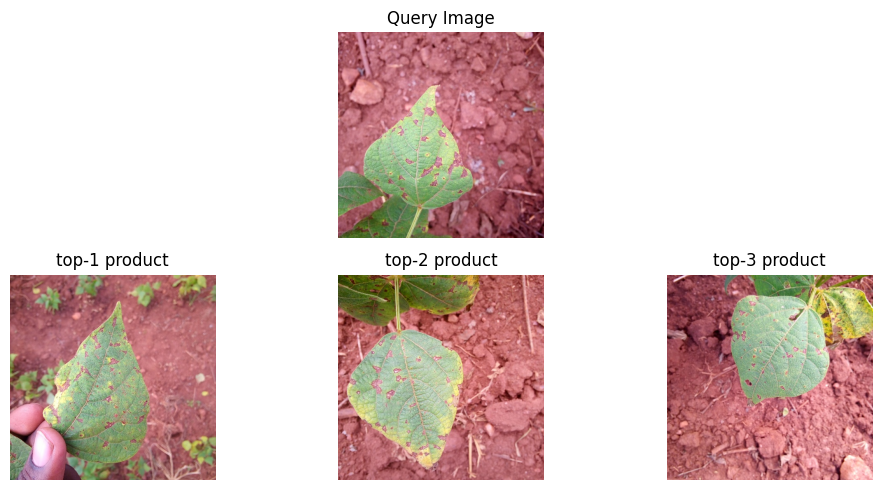

In [16]:
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])

ax0 = plt.subplot(gs[0, :])
ax0.imshow(dataset[search_index]['image'])
ax0.axis('off')
ax0.set_title('Query Image')

for i, pic in enumerate(result):
    ax = plt.subplot(gs[1, i])
    ax.imshow(dataset[pic]['image'])
    ax.axis('off')
    ax.set_title(f'top-{i+1} product')

plt.tight_layout()
plt.show()

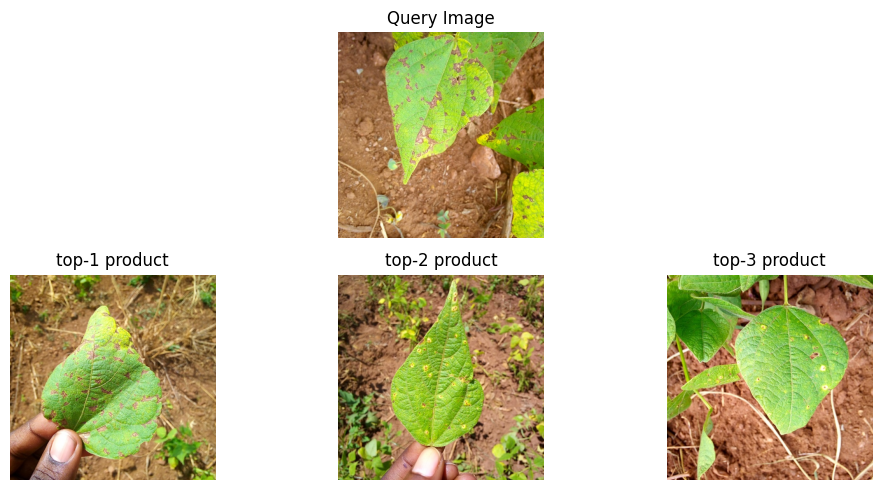

In [17]:
search_index = 94
result = search(search_index)

plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])

ax0 = plt.subplot(gs[0, :])
ax0.imshow(dataset[search_index]['image'])
ax0.axis('off')
ax0.set_title('Query Image')

for i, pic in enumerate(result):
    ax = plt.subplot(gs[1, i])
    ax.imshow(dataset[pic]['image'])
    ax.axis('off')
    ax.set_title(f'top-{i+1} product')

plt.tight_layout()
plt.show()

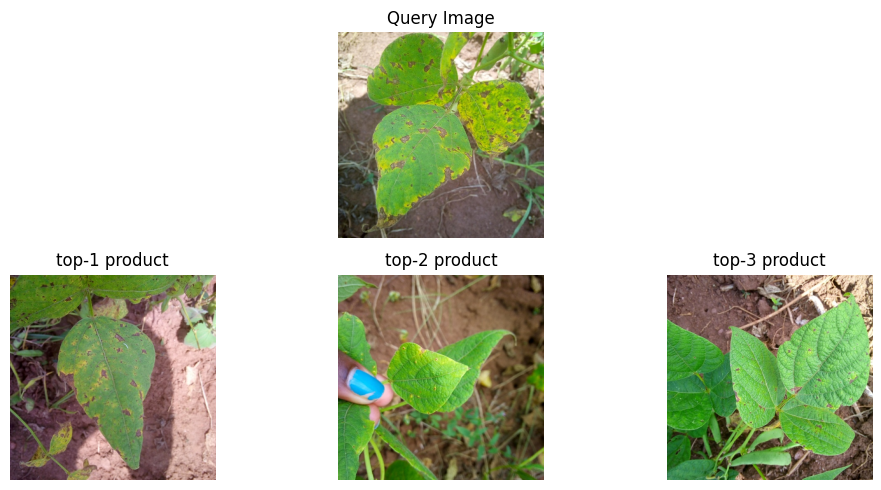

In [18]:
search_index = 155
result = search(search_index)
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1])

ax0 = plt.subplot(gs[0, :])
ax0.imshow(dataset[search_index]['image'])
ax0.axis('off')
ax0.set_title('Query Image')

for i, pic in enumerate(result):
    ax = plt.subplot(gs[1, i])
    ax.imshow(dataset[pic]['image'])
    ax.axis('off')
    ax.set_title(f'top-{i+1} product')

plt.tight_layout()
plt.show()

색감이 비슷한 애들끼리 나오는듯